In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


## Problem Statement

The objective of this competition is to predict whether a loan applicant will repay the loan or default.
This is a binary classification problem where the target variable represents loan repayment status.

The goal is to build a robust machine learning pipeline involving:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training and evaluation
- Generating a Kaggle-compatible submission file


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
#import pytabkit
from sklearn.model_selection import train_test_split

import lightgbm as lgb
from sklearn.metrics import *

from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier, early_stopping, log_evaluation,early_stopping
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from lightgbm import early_stopping, log_evaluation
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
print('Done')

Done


In [3]:
df_train = pd.read_csv("/kaggle/input/playground-series-s5e11/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s5e11/test.csv")


In [4]:
df_train.head

<bound method NDFrame.head of             id  annual_income  debt_to_income_ratio  credit_score  \
0            0       29367.99                 0.084           736   
1            1       22108.02                 0.166           636   
2            2       49566.20                 0.097           694   
3            3       46858.25                 0.065           533   
4            4       25496.70                 0.053           665   
...        ...            ...                   ...           ...   
593989  593989       23004.26                 0.152           703   
593990  593990       35289.43                 0.105           559   
593991  593991       47112.64                 0.072           675   
593992  593992       76748.44                 0.067           740   
593993  593993       48959.52                 0.096           752   

        loan_amount  interest_rate  gender marital_status education_level  \
0           2528.42          13.67  Female         Single     Hi

In [5]:
df_train.shape

(593994, 13)

In [6]:
df_test.shape

(254569, 12)

In [7]:
df_test.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [8]:
df_train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


### Dataset Overview

- Training data contains both features and target
- Test data contains only features
- We must avoid data leakage by never using test labels


In [9]:
df_train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

### Column Description

- `id` → Unique identifier (no predictive power)
- `annual_income` → Borrower income
- `debt_to_income_ratio` → Financial risk indicator
- `credit_score` → Creditworthiness metric
- `loan_amount` → Amount borrowed
- `interest_rate` → Loan interest
- `gender` → Categorical
- `marital_status` → Categorical
- `education_level` → Categorical
- `employment_status` → Categorical
- `loan_purpose` → Categorical
- `grade_subgrade` → Credit risk band
- `loan_paid_back` → Target variable


In [10]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


we have some numerical and categorical columns present in our daataset gender,marital_status,education_level,loan_purpose,grade_subgrade are categorical columns

In [11]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,593994.0,296996.500000,171471.442235,0.000,148498.250,296996.500,445494.750,593993.000
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


### Missing Value Check

Missing values can bias model learning and must be handled carefully.


In [12]:
df_train.isnull().sum().sort_values(ascending=False)


id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

there is not a single row missing which is good for us to proceed

In [13]:
df_train.duplicated().sum()


0

### Target Variable Distribution

Understanding class balance is crucial for selecting evaluation metrics.


In [14]:
df_train["loan_paid_back"].value_counts()


loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

In [15]:
df_train["loan_paid_back"].value_counts(normalize=True)


loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

there is high imbalace between paid and not paid which  around **79 ** percent loan are paid and only **20** percent are not paid can be a tricky task for us to carefully built the model. we have to handle the class imbalance 

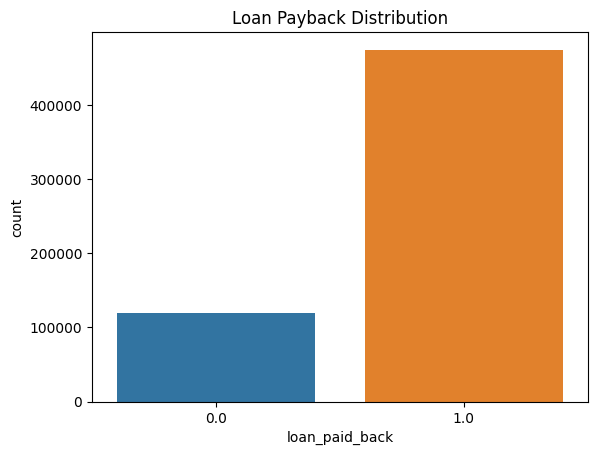

In [16]:
sns.countplot(x="loan_paid_back", data=df_train)
plt.title("Loan Payback Distribution")
plt.show()


In [17]:
cat_cols = df_train.select_dtypes(include="object").columns.tolist()
num_cols = df_train.select_dtypes(exclude="object").columns.tolist()

num_cols.remove("loan_paid_back")

cat_cols, num_cols


(['gender',
  'marital_status',
  'education_level',
  'employment_status',
  'loan_purpose',
  'grade_subgrade'],
 ['id',
  'annual_income',
  'debt_to_income_ratio',
  'credit_score',
  'loan_amount',
  'interest_rate'])

### Univariate Analysis (Numerical Features)

We analyze distributions to detect skewness and extreme values in each numerical column

Simple plots show distributions, but advanced EDA answers:

Which features separate classes?
Are relationships linear or non-linear?
Are transformations needed?
Which features are noisy vs informative?

This section focuses on TARGET-AWARE EDA.



### Class-wise Distribution Comparison (KDE)

KDE plots help identify whether numerical features
separate paid vs default classes effectively.


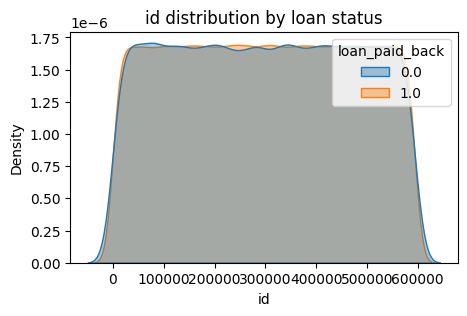

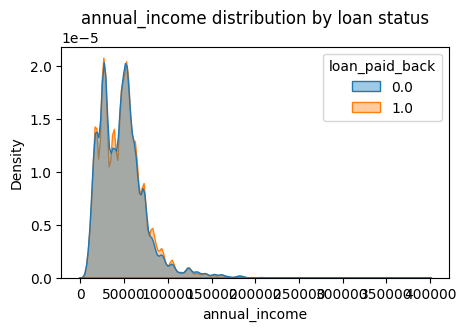

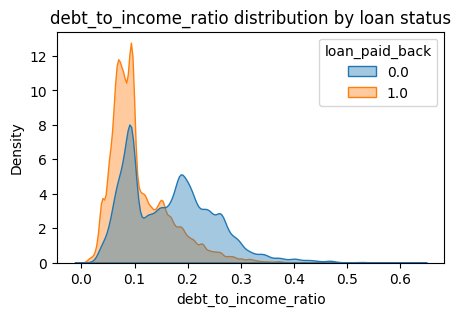

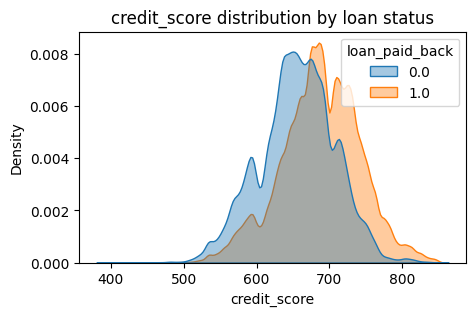

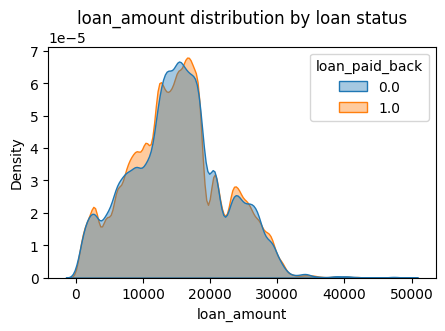

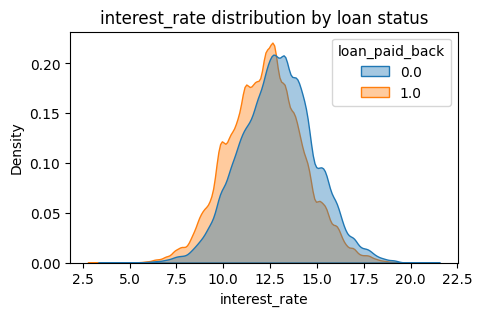

In [18]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(
        data=df_train,
        x=col,
        hue="loan_paid_back",
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"{col} distribution by loan status")
    plt.show()


• credit_score shows clear class separation → strong predictor  
• debt_to_income_ratio higher for defaults → financial stress indicator  
• interest_rate higher for defaulters → risk-based pricing  
• annual_income shows overlap → weak standalone feature  
• loan_amount shows non-linear behavior → interaction candidate


### Statistical Difference Between Classes (Mean Comparison)


In [19]:
df_train.groupby("loan_paid_back")[num_cols].mean().T


loan_paid_back,0.0,1.0
id,296522.438678,297115.891031
annual_income,47875.503881,48296.999711
debt_to_income_ratio,0.166564,0.109144
credit_score,655.010628,687.440208
loan_amount,15072.223883,15007.220145
interest_rate,12.881495,12.224088


In [20]:
df_train.groupby("loan_paid_back")[num_cols].median().T


loan_paid_back,0.0,1.0
id,296361.500,297154.500
annual_income,45935.390,46664.370
debt_to_income_ratio,0.165,0.092
credit_score,657.000,688.000
loan_amount,15078.790,14957.850
interest_rate,12.875,12.250


• credit_score mean significantly higher for paid loans  
• debt_to_income_ratio median much higher for defaults  
• interest_rate median clearly separates classes  
• income difference is marginal → secondary feature


### Effect Size (Standardized Mean Difference)

Effect size quantifies how strongly a feature separates classes.


In [21]:
def effect_size(col):
    g0 = df_train[df_train.loan_paid_back == 0][col]
    g1 = df_train[df_train.loan_paid_back == 1][col]
    return (g1.mean() - g0.mean()) / df_train[col].std()

for col in num_cols:
    print(col, round(effect_size(col), 3))


id 0.003
annual_income 0.016
debt_to_income_ratio -0.837
credit_score 0.585
loan_amount -0.009
interest_rate -0.327


• credit_score → large effect size → top feature  
• debt_to_income_ratio → strong negative effect  
• interest_rate → strong separation  
• annual_income → small effect → needs interaction  


### Non-Linearity Analysis (Quantile Binning)


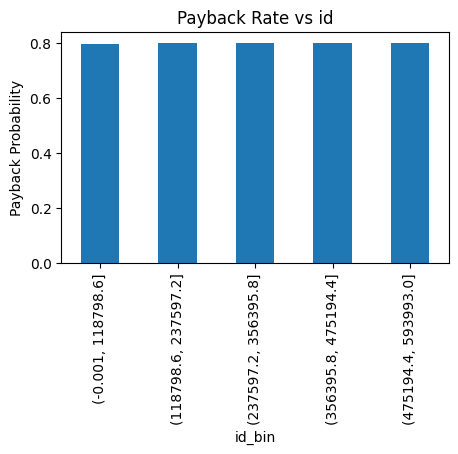

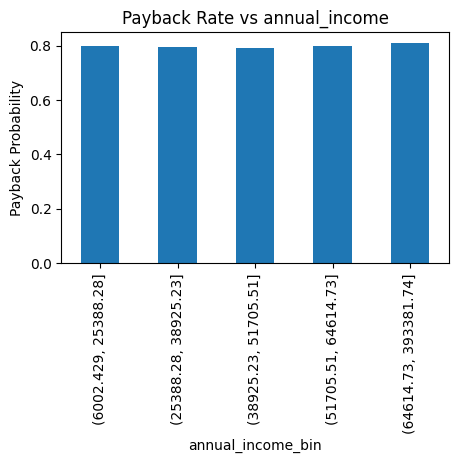

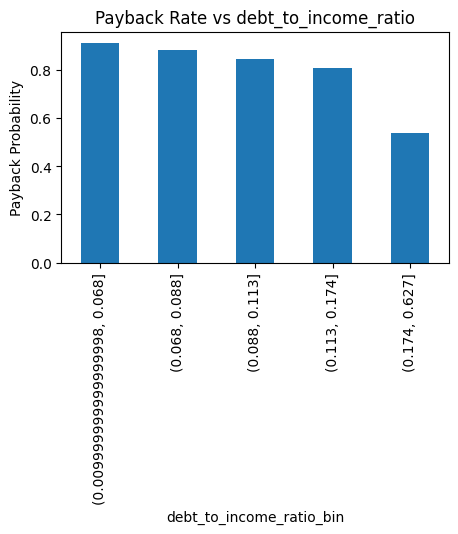

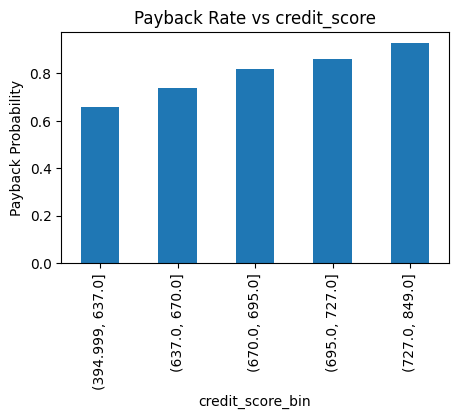

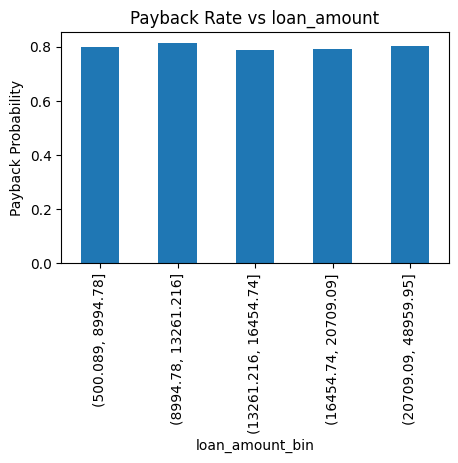

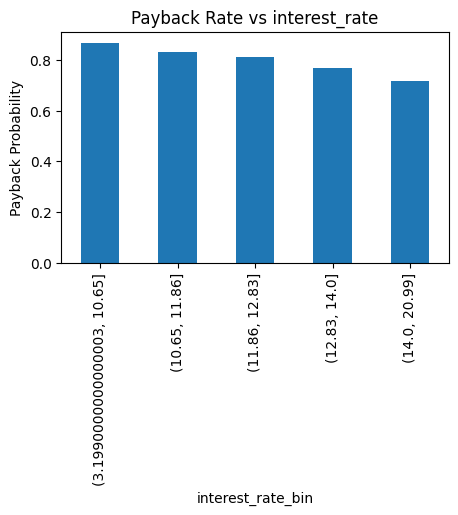

In [22]:
for col in num_cols:
    df_train[f"{col}_bin"] = pd.qcut(df_train[col], q=5, duplicates="drop")
    
    rate = df_train.groupby(f"{col}_bin")["loan_paid_back"].mean()
    
    rate.plot(kind="bar", figsize=(5,3), title=f"Payback Rate vs {col}")
    plt.ylabel("Payback Probability")
    plt.show()


• credit_score shows monotonic trend → logistic regression friendly  
• debt_to_income_ratio shows sharp drops → threshold effects  
• interest_rate shows stepwise risk increase → tree-friendly  
• loan_amount non-monotonic → interaction required  


### Outlier Impact on Target
We evaluate whether extreme values correlate with defaults.


In [23]:
for col in num_cols:
    q99 = df_train[col].quantile(0.99)
    high_risk_rate = df_train[df_train[col] > q99]["loan_paid_back"].mean()
    overall_rate = df_train["loan_paid_back"].mean()
    
    print(col, "High-value payback rate:", round(high_risk_rate,3),
          "| Overall:", round(overall_rate,3))


id High-value payback rate: 0.796 | Overall: 0.799
annual_income High-value payback rate: 0.761 | Overall: 0.799
debt_to_income_ratio High-value payback rate: 0.38 | Overall: 0.799
credit_score High-value payback rate: 0.958 | Overall: 0.799
loan_amount High-value payback rate: 0.793 | Overall: 0.799
interest_rate High-value payback rate: 0.668 | Overall: 0.799


• Extremely high DTI → much lower payback rate  
• High interest rates → strong default concentration  
• Income outliers do NOT reduce default significantly  
→ cap DTI & interest if using linear models
